In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv('C:\\Users\\Harsh Kumar\\Desktop\\5th sem\\ML\\lab+lab project\\my2026-fuel-consumption-ratings.csv')
print(data.head())

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\Harsh Kumar\\Desktop\\5th sem\\ML\\lab+lab project\\my2026-fuel-consumption-ratings.csv'

In [ ]:
data['Transmission'].value_counts()

Transmission
AS8     136
A10      47
A8       45
AS10     39
AV       29
AM7      23
M6       18
AS6      16
AS9      13
AM6       9
AV6       8
AV1       7
AV8       7
AM8       6
A9        5
AV10      4
A6        2
Name: count, dtype: int64

In [ ]:
numeric_features = ['Engine size (L)', 'Cylinders', 'Combined (L/100 km)']

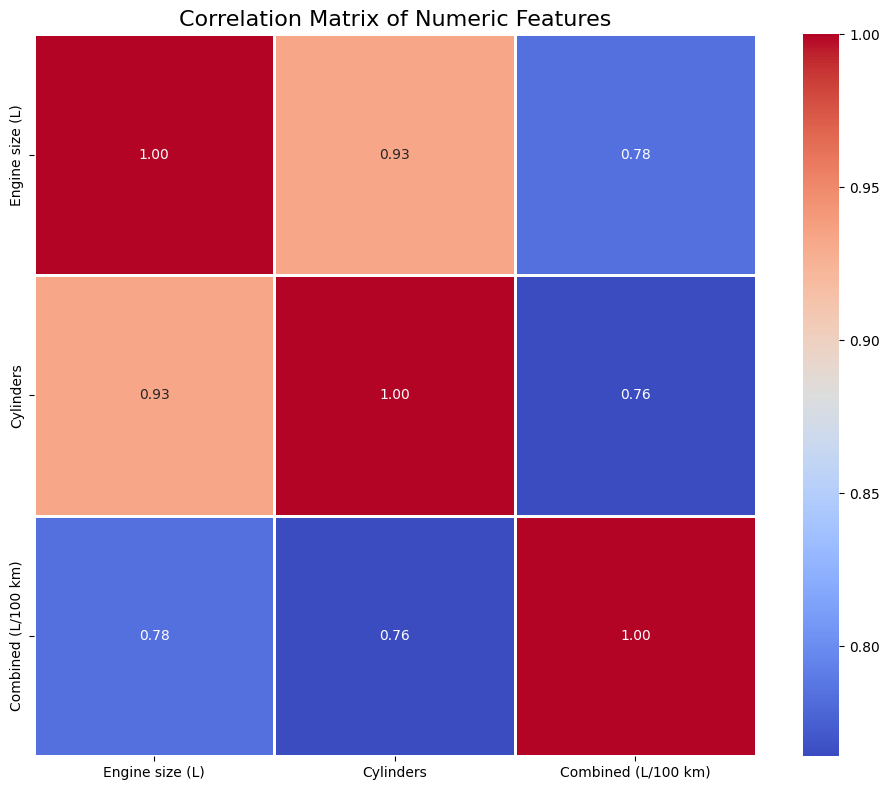

In [ ]:
# Correlation heatmap for numeric features
plt.figure(figsize=(10, 8))
correlation_matrix = data[numeric_features].corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', square=True, linewidths=1)
plt.title('Correlation Matrix of Numeric Features', fontsize=16)
plt.tight_layout()
plt.show()

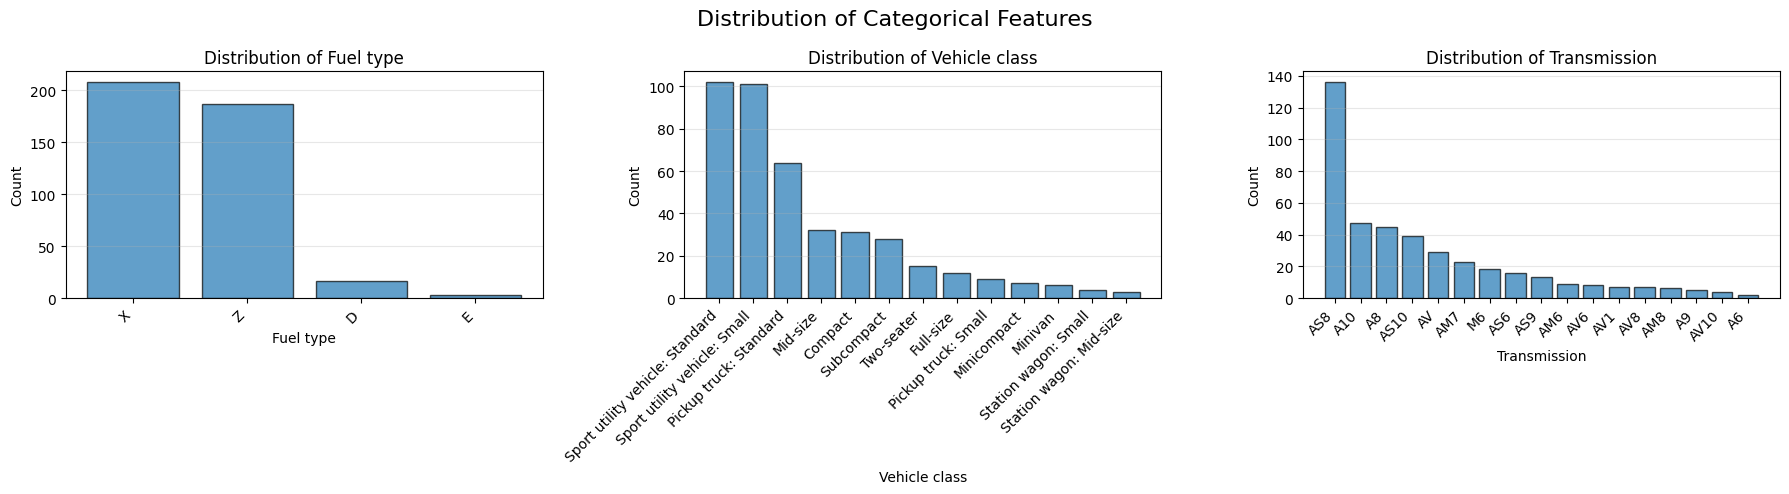

In [ ]:
# Plot distribution of categorical features
categorical_features = ['Fuel type', 'Vehicle class', 'Transmission']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Distribution of Categorical Features', fontsize=16)

for idx, feature in enumerate(categorical_features):
    value_counts = data[feature].value_counts()
    axes[idx].bar(range(len(value_counts)), value_counts.values, edgecolor='black', alpha=0.7)
    axes[idx].set_xlabel(feature)
    axes[idx].set_ylabel('Count')
    axes[idx].set_title(f'Distribution of {feature}')
    axes[idx].set_xticks(range(len(value_counts)))
    axes[idx].set_xticklabels(value_counts.index, rotation=45, ha='right')
    axes[idx].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

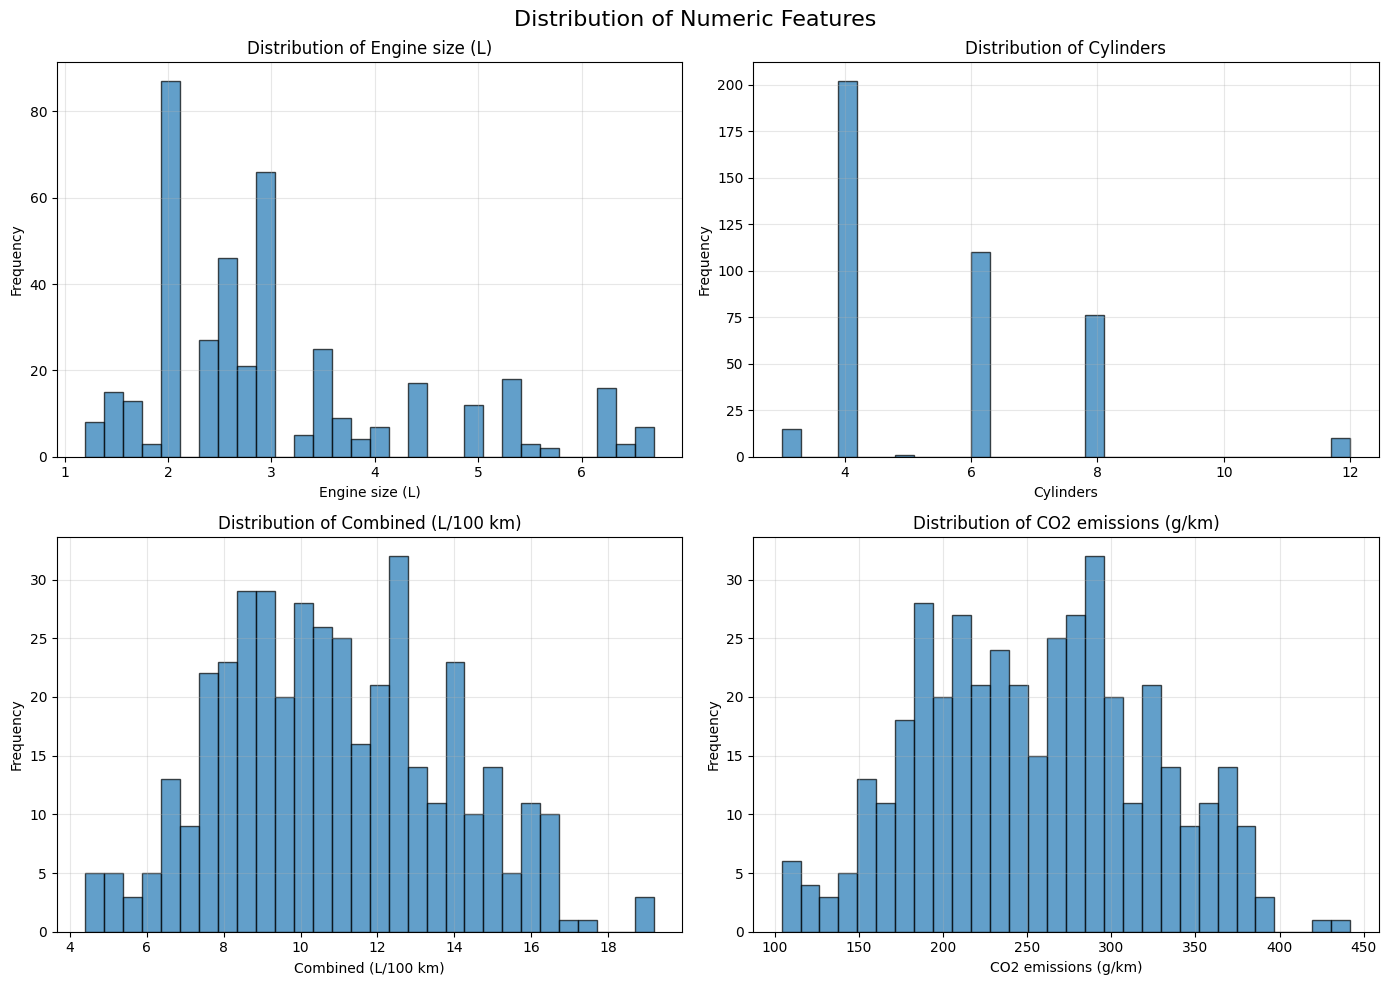

In [ ]:
# Plot distribution of numeric features
numeric_features = ['Engine size (L)', 'Cylinders', 'Combined (L/100 km)', 'CO2 emissions (g/km)']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Distribution of Numeric Features', fontsize=16)

for idx, feature in enumerate(numeric_features):
    row = idx // 2
    col = idx % 2
    axes[row, col].hist(data[feature], bins=30, edgecolor='black', alpha=0.7)
    axes[row, col].set_xlabel(feature)
    axes[row, col].set_ylabel('Frequency')
    axes[row, col].set_title(f'Distribution of {feature}')
    axes[row, col].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
    # numeric_features = ['Engine size (L)', 'Cylinders', 'Combined (L/100 km)']
    # categorical_features = ['Fuel type', 'Vehicle class', 'Transmission']
    # features = numeric_features + categorical_features
    # target = 'CO2 emissions (g/km)'
    # print(features)

    # X = data[features]
    # y = data[target]

    # X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    # print(f"Data split: {len(X_train)} training samples, {len(X_test)} testing samples.")
    # print("-" * 50)

    # preprocessor = ColumnTransformer(
    #     transformers=[
    #         ('num', 'passthrough', numeric_features),
    #         ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    #     ]
    # )

    # print("Training Linear Regression model...")
    # lr_pipeline = Pipeline(steps=[
    #     ('preprocessor', preprocessor),
    #     ('model', LinearRegression())
    # ])
    # lr_pipeline.fit(X_train, y_train)
    # print("Linear Regression training complete.")

    # # Linear Regression Evaluation
    # lr_preds = lr_pipeline.predict(X_test)
    # lr_mae = mean_absolute_error(y_test, lr_preds)
    # lr_r2 = r2_score(y_test, lr_preds)
    # print("\n--- Linear Regression Performance ---")
    # print(f"Mean Absolute Error (MAE): {lr_mae:.2f} g/km")
    # print(f"R-squared (R²) Score:     {lr_r2:.4f}")


    #   # --- 6. Model 2: Random Forest ---
    # print("Training Random Forest model...")
    # rf_pipeline = Pipeline(steps=[
    #     ('preprocessor', preprocessor),
    #     ('model', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))
    # ])
    # rf_pipeline.fit(X_train, y_train)
    # print("Random Forest training complete.")
    # print("-" * 50)

    # #Random forest evaluation
    # rf_preds = rf_pipeline.predict(X_test)
    # rf_mae = mean_absolute_error(y_test, rf_preds)
    # rf_r2 = r2_score(y_test, rf_preds)
    # print("\n--- Random Forest Performance ---")
    # print(f"Mean Absolute Error (MAE): {rf_mae:.2f} g/km")
    # print(f"R-squared (R²) Score:     {rf_r2:.4f}")
    # print("-" * 50)

In [ ]:
def main():
    """Main function to run the ML workflow."""

    numeric_features = ['Engine size (L)', 'Cylinders', 'Combined (L/100 km)']
    categorical_features = ['Fuel type', 'Vehicle class', 'Transmission']
    features = numeric_features + categorical_features
    target = 'CO2 emissions (g/km)'
    print(features)

    X = data[features]
    y = data[target]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    print(f"Data split: {len(X_train)} training samples, {len(X_test)} testing samples.")
    print("-" * 50)

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', 'passthrough', numeric_features),
            ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
        ]
    )

    print("Training Linear Regression model...")
    lr_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', LinearRegression())
    ])
    lr_pipeline.fit(X_train, y_train)
    print("Linear Regression training complete.")

    # Linear Regression Evaluation
    lr_preds = lr_pipeline.predict(X_test)
    lr_mae = mean_absolute_error(y_test, lr_preds)
    lr_r2 = r2_score(y_test, lr_preds)
    print("\n--- Linear Regression Performance ---")
    print(f"Mean Absolute Error (MAE): {lr_mae:.2f} g/km")
    print(f"R-squared (R²) Score:     {lr_r2:.4f}")
    print("-" * 50)

      # --- 6. Model 2: Random Forest ---
    print("Training Random Forest model...")
    rf_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))
    ])
    rf_pipeline.fit(X_train, y_train)
    print("Random Forest training complete.")
    print("-" * 50)

    #Random forest evaluation
    rf_preds = rf_pipeline.predict(X_test)
    rf_mae = mean_absolute_error(y_test, rf_preds)
    rf_r2 = r2_score(y_test, rf_preds)
    print("\n--- Random Forest Performance ---")
    print(f"Mean Absolute Error (MAE): {rf_mae:.2f} g/km")
    print(f"R-squared (R²) Score:     {rf_r2:.4f}")
    print("-" * 50)

    print("Training Gradient Boosting model...")
    gbr_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', GradientBoostingRegressor(n_estimators=300, learning_rate=0.05, max_depth=5, random_state=42))
    ])
    gbr_pipeline.fit(X_train, y_train)
    print("GBR training complete.")
    print("-" * 50)

    #GBR evalution
    gbr_preds = gbr_pipeline.predict(X_test)
    gbr_mae = mean_absolute_error(y_test, gbr_preds)
    gbr_r2 = r2_score(y_test, gbr_preds)
    print("\n--- GBR Performance ---")
    print(f"Mean Absolute Error (MAE): {gbr_mae:.2f} g/km")
    print(f"R-squared (R²) Score:     {gbr_r2:.4f}")
    print("-" * 50)

    # ===== SAVE ALL MODELS =====
    print("\n💾 Saving all models...")
    
    # Save each model separately
    joblib.dump(lr_pipeline, 'lr_model.joblib')
    print("✅ Linear Regression saved to 'lr_model.joblib'")
    
    joblib.dump(rf_pipeline, 'rf_model.joblib')
    print("✅ Random Forest saved to 'rf_model.joblib'")
    
    joblib.dump(gbr_pipeline, 'gbr_model.joblib')
    print("✅ Gradient Boosting saved to 'gbr_model.joblib'")
    
    # Save default model (change this to your preferred model)
    joblib.dump(gbr_pipeline, 'co2_model.joblib')  # Currently using GBR as default
    print("✅ Default model saved to 'co2_model.joblib' (GBR)")
    print("-" * 50)
    
    print("\n📊 Model Summary:")
    print(f"   LR  - MAE: {lr_mae:.2f} g/km, R²: {lr_r2:.4f}")
    print(f"   RF  - MAE: {rf_mae:.2f} g/km, R²: {rf_r2:.4f}")
    print(f"   GBR - MAE: {gbr_mae:.2f} g/km, R²: {gbr_r2:.4f}")
    print("=" * 50)
    
    return lr_pipeline, rf_pipeline, gbr_pipeline


In [ ]:
if __name__ == "__main__":
    main()

['Engine size (L)', 'Cylinders', 'Combined (L/100 km)', 'Fuel type', 'Vehicle class', 'Transmission']
Data split: 331 training samples, 83 testing samples.
--------------------------------------------------
Training Linear Regression model...
Linear Regression training complete.

--- Linear Regression Performance ---
Mean Absolute Error (MAE): 1.39 g/km
R-squared (R²) Score:     0.9993
--------------------------------------------------
Training Random Forest model...
Random Forest training complete.
--------------------------------------------------

--- Random Forest Performance ---
Mean Absolute Error (MAE): 2.46 g/km
R-squared (R²) Score:     0.9878
--------------------------------------------------
Training Gradient Boosting model...
Random Forest training complete.
--------------------------------------------------

--- Random Forest Performance ---
Mean Absolute Error (MAE): 2.46 g/km
R-squared (R²) Score:     0.9878
--------------------------------------------------
Training Gra